In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img_, cmap=None, title=None):
    plt.imshow(img_, cmap=cmap); plt.axis('off')
    if title: plt.title(title)
    plt.show()

def show_row(items):
    plt.figure(figsize=(4 * len(items), 4))
    for i, (title, im, cmap) in enumerate(items, 1):
        plt.subplot(1, len(items), i)
        plt.imshow(im, cmap=cmap, vmin=0, vmax=255)
        plt.axis('off'); plt.title(title, fontsize=10)
    plt.tight_layout(); plt.show()


In [7]:
def extract_ball(mask, resized, area_fraction=0.18, label="Ball"):
    total_pixels = cv2.countNonZero(mask)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    best_contour = None
    best_score = 0
    for c in contours:
        area = cv2.contourArea(c)
        if label == "Blue Ball":
            area_fraction = 0.12
        if total_pixels == 0 or area < area_fraction * total_pixels :
            continue
        perimeter = cv2.arcLength(c, True)
        if perimeter == 0:
            continue
        circularity = 4 * np.pi * area / (perimeter ** 2)

        M = cv2.moments(c)
        cx, cy = M['m10']/M['m00'], M['m01']/M['m00']
        pts = c.reshape(-1, 2)
        dists = np.sqrt((pts[:,0]-cx)**2 + (pts[:,1]-cy)**2)
        roundness = 1 - (np.std(dists) / np.mean(dists))
        
        if roundness > best_score:
            best_score = roundness
            best_contour = c


    if best_contour is None:
        print(f"No {label.lower()} found")
        return None, None

    ball_mask = np.zeros_like(mask)
    cv2.drawContours(ball_mask, [best_contour], -1, 255, thickness=cv2.FILLED)
    ball_only = cv2.bitwise_and(resized, resized, mask=ball_mask)

    ball_gray = cv2.cvtColor(ball_only, cv2.COLOR_BGR2GRAY)
    return ball_only, ball_gray

In [8]:
def detect_circle(ball_gray, resized, label="Ball", color=(0, 255, 0), min = 10):
    if ball_gray is None:
        print(f"No {label.lower()} to detect a circle in")
        return None

    if label == "Red Ball":
        param1 = 20

    elif label == "Blue Ball":
        param1 = 35  

    blurred = cv2.GaussianBlur(ball_gray, (9, 9), 25)
    circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1, minDist=20,
                                param1=param1, param2=20, minRadius=min , maxRadius=10000)

    if circles is None:
        print(f"No circle found for {label}")
        return None

    circles = np.round(circles[0, :]).astype(int)
    x, y, r = circles[0]  # or pick the best among multiple by some criterion

    cv2.circle(resized, (x, y), r, color, 5)
    print(f"{label}: center=({x},{y}) r={r}, {len(circles)} circle(s) detected")

    return (x, y, r)



--- balls/ball_1.jpg (1080x1920) ---


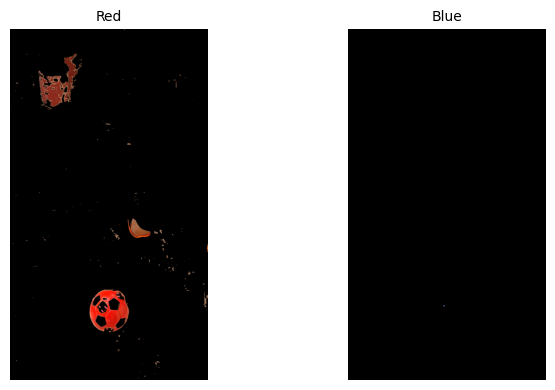

Red Ball: center=(540,1544) r=110, 175 circle(s) detected
No circle found for Blue Ball


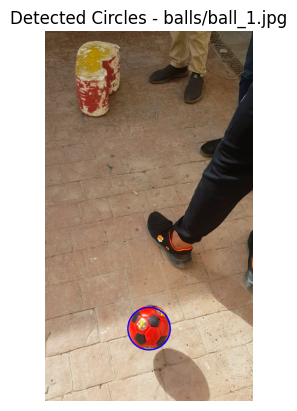

--- balls/ball_2.jpg (1836x3264) ---


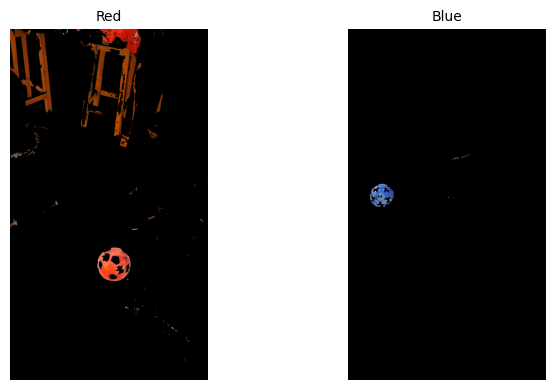

Red Ball: center=(960,2186) r=150, 234 circle(s) detected
Blue Ball: center=(334,1534) r=91, 132 circle(s) detected


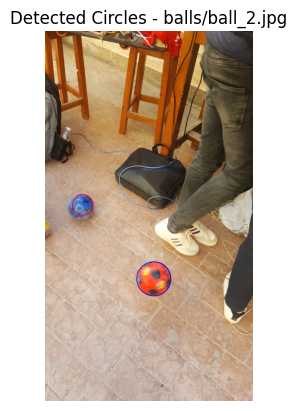

--- balls/ball_3.jpg (443x960) ---


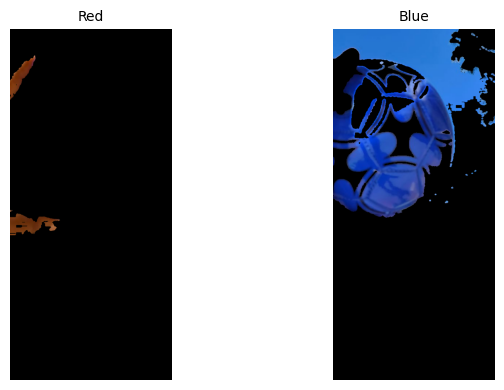

No circle found for Red Ball
Blue Ball: center=(146,304) r=191, 293 circle(s) detected


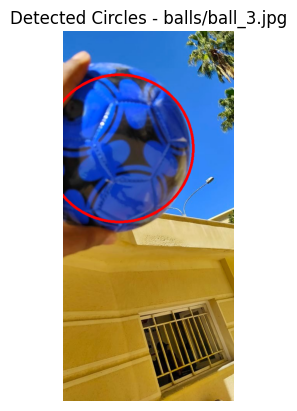

--- balls/ball_4.jpg (443x960) ---


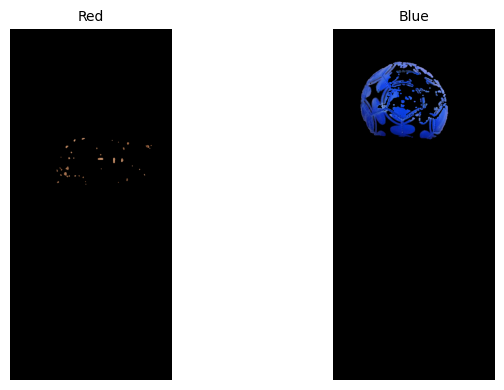

No red ball found
No red ball to detect a circle in
Blue Ball: center=(172,198) r=96, 76 circle(s) detected


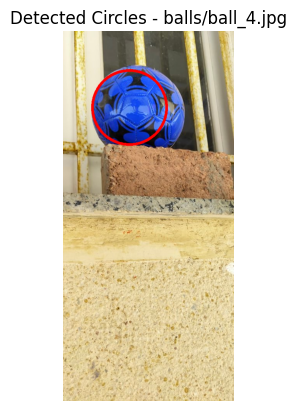

--- balls/ball_5.jpg (443x960) ---


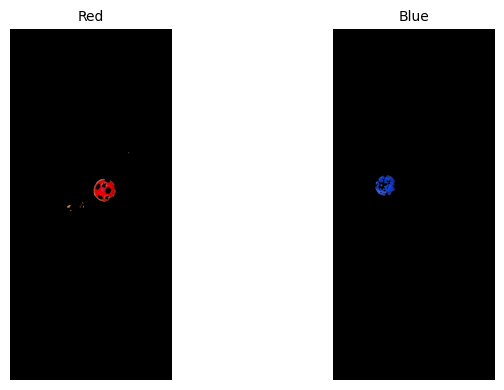

Red Ball: center=(258,442) r=32, 2 circle(s) detected
Blue Ball: center=(142,428) r=25, 1 circle(s) detected


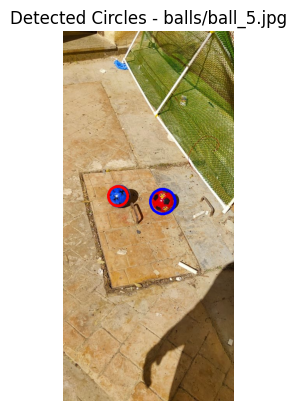

--- balls/ball_6.jpg (443x960) ---


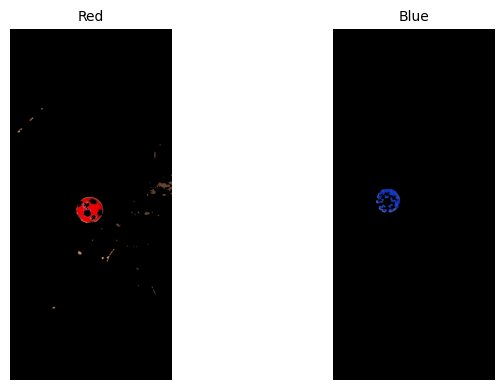

Red Ball: center=(218,494) r=30, 3 circle(s) detected
Blue Ball: center=(150,468) r=31, 1 circle(s) detected


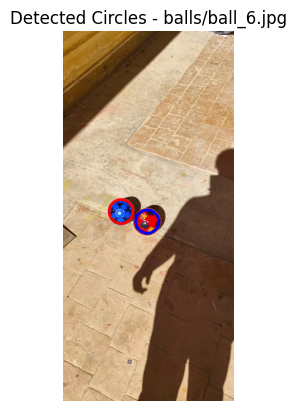

--- balls/ball_7.jpg (960x443) ---


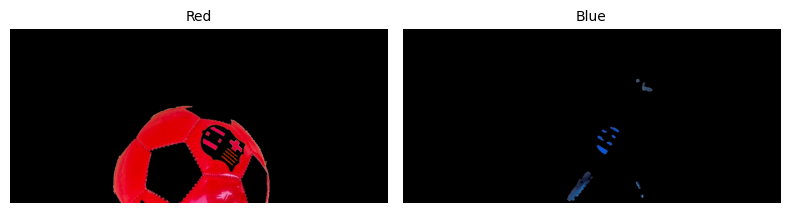

Red Ball: center=(460,398) r=190, 204 circle(s) detected
No circle found for Blue Ball


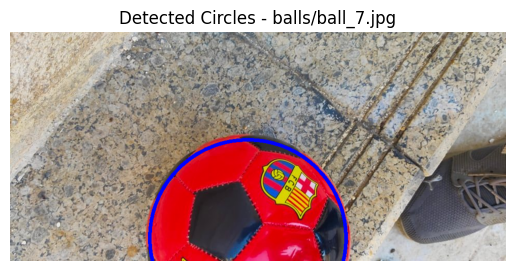

--- balls/ball_8.jpg (1080x1920) ---


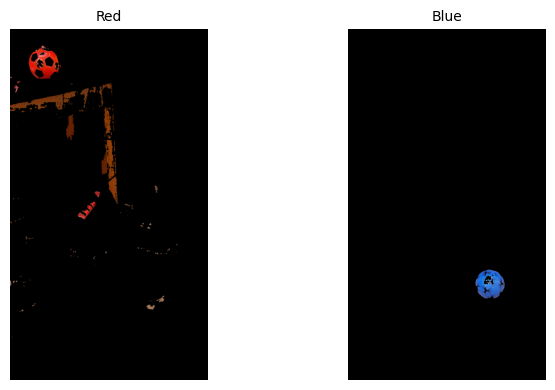

Red Ball: center=(168,184) r=68, 72 circle(s) detected
Blue Ball: center=(774,1398) r=78, 19 circle(s) detected


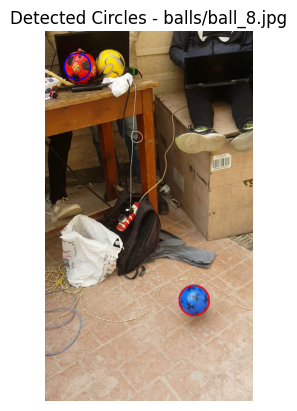

--- balls/ball_9.jpg (1080x1920) ---


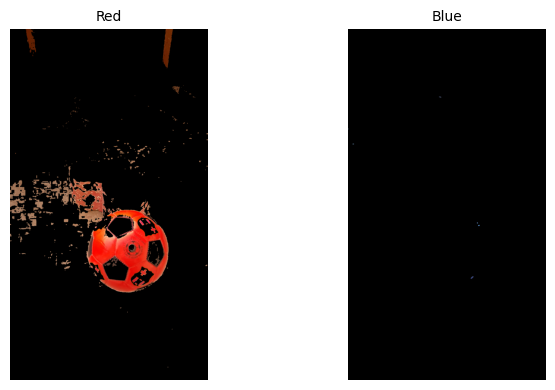

Red Ball: center=(638,1214) r=220, 1173 circle(s) detected
No circle found for Blue Ball


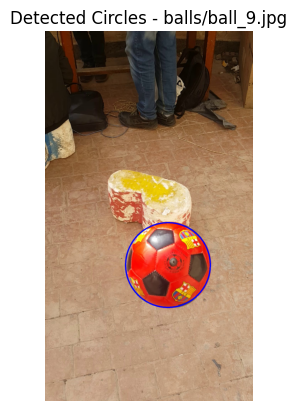

--- balls/ball_10.jpg (3264x1836) ---


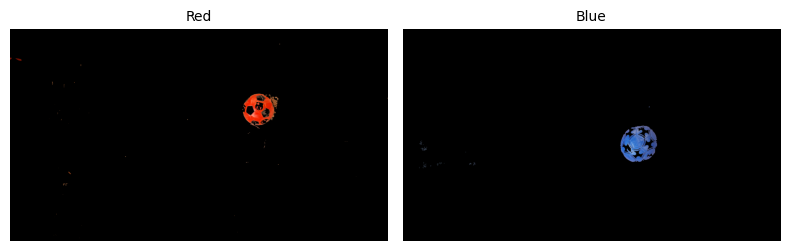

Red Ball: center=(2144,706) r=135, 396 circle(s) detected
Blue Ball: center=(2008,1034) r=120, 266 circle(s) detected


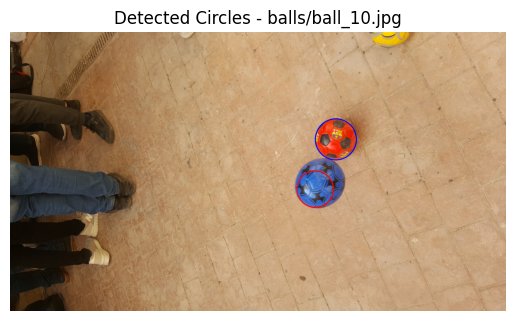

--- balls/ball_11.jpg (3264x1836) ---


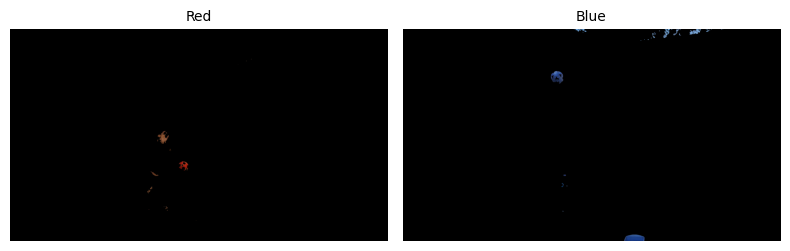

Red Ball: center=(1496,1188) r=41, 4 circle(s) detected
Blue Ball: center=(1324,432) r=56, 7 circle(s) detected


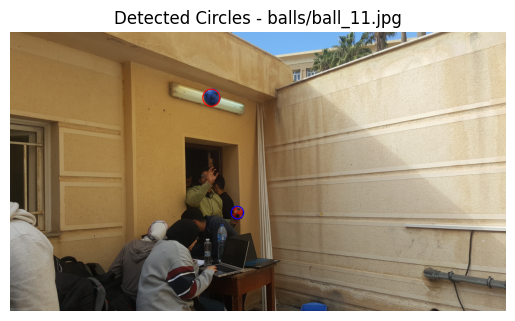

--- balls/ball_12.jpg (443x960) ---


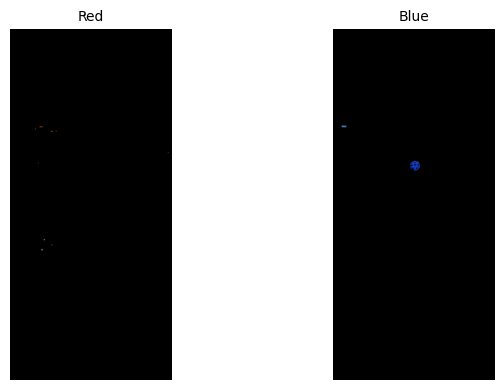

No red ball found
No red ball to detect a circle in
Blue Ball: center=(224,372) r=12, 1 circle(s) detected


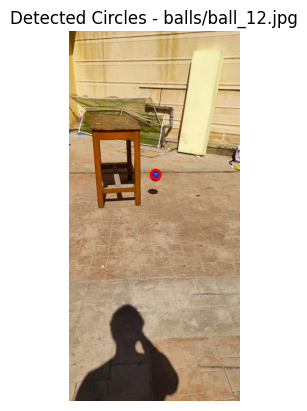

--- balls/ball_13.jpg (1836x3264) ---


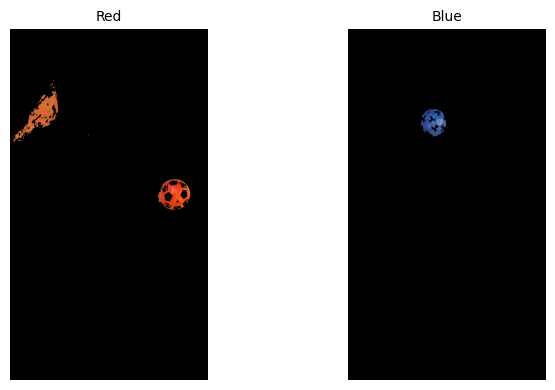

Red Ball: center=(1526,1534) r=140, 379 circle(s) detected
Blue Ball: center=(794,854) r=111, 125 circle(s) detected


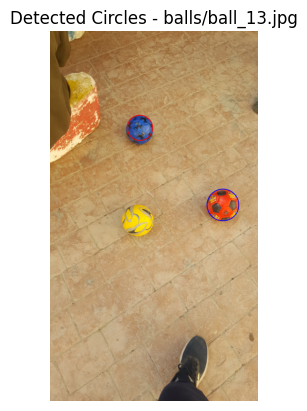

--- balls/ball_14.jpg (443x960) ---


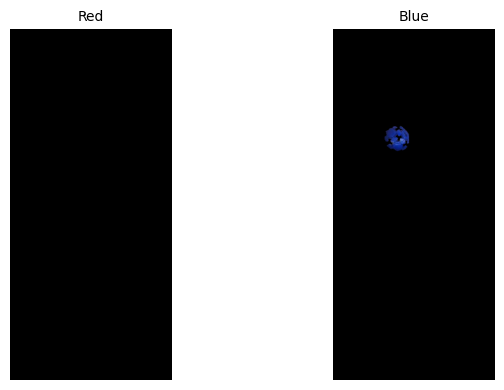

No red ball found
No red ball to detect a circle in
Blue Ball: center=(176,300) r=34, 1 circle(s) detected


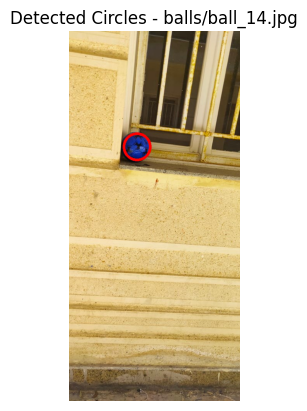

--- balls/ball_15.jpg (443x960) ---


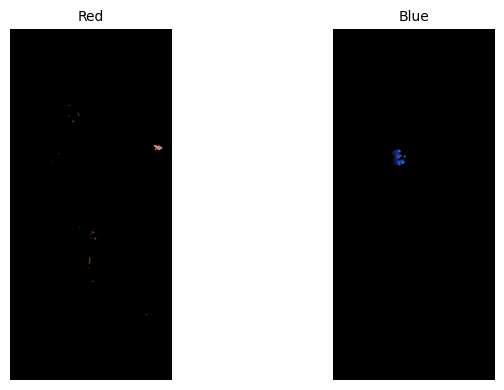

No circle found for Red Ball
Blue Ball: center=(184,358) r=13, 1 circle(s) detected


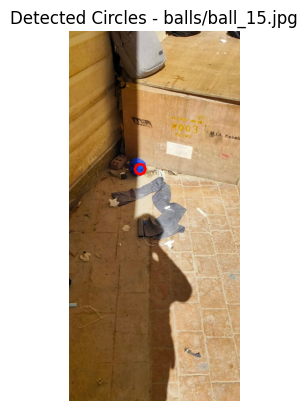

--- balls/ball_16.jpg (443x960) ---


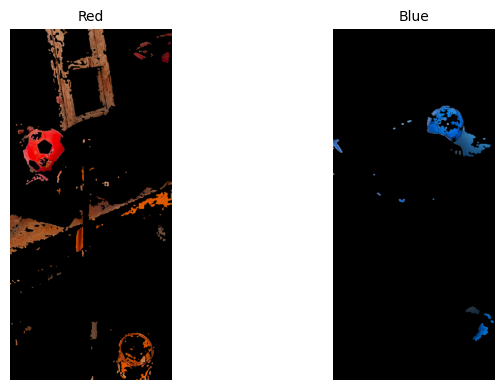

Red Ball: center=(104,316) r=46, 22 circle(s) detected
Blue Ball: center=(312,252) r=42, 12 circle(s) detected


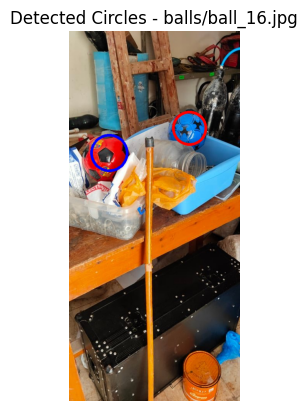

--- balls/ball_17.jpg (443x960) ---


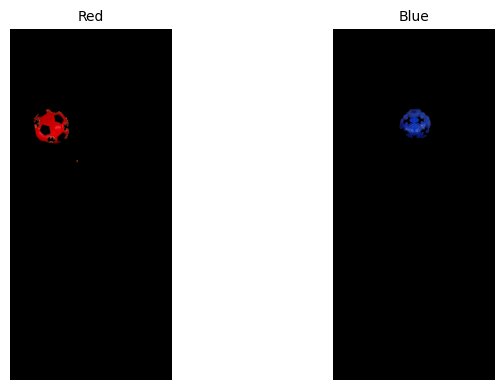

Red Ball: center=(122,260) r=40, 5 circle(s) detected
Blue Ball: center=(220,250) r=34, 5 circle(s) detected


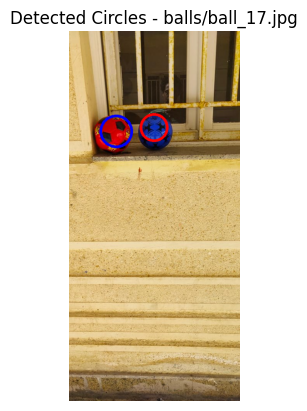

--- balls/ball_18.jpg (1836x3264) ---


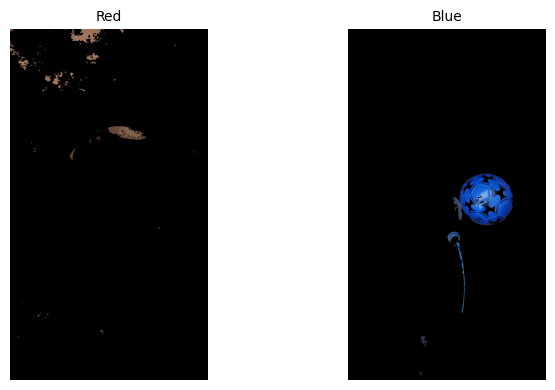

Red Ball: center=(804,68) r=39, 3 circle(s) detected
Blue Ball: center=(1264,1570) r=228, 861 circle(s) detected


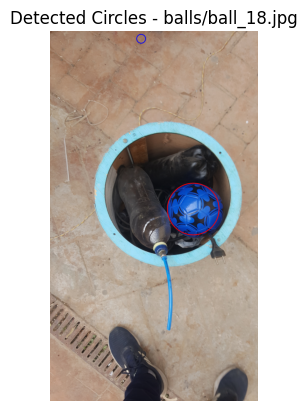

--- balls/ball_19.jpg (1836x3264) ---


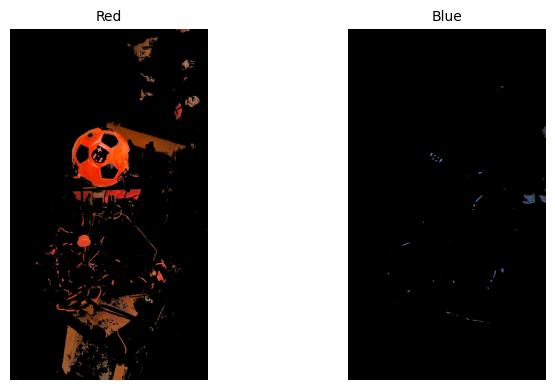

Red Ball: center=(906,1202) r=190, 2086 circle(s) detected
No circle found for Blue Ball


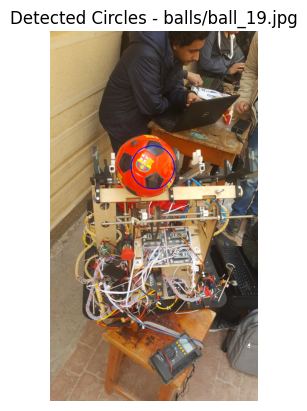

--- balls/ball_20.jpg (1836x3264) ---


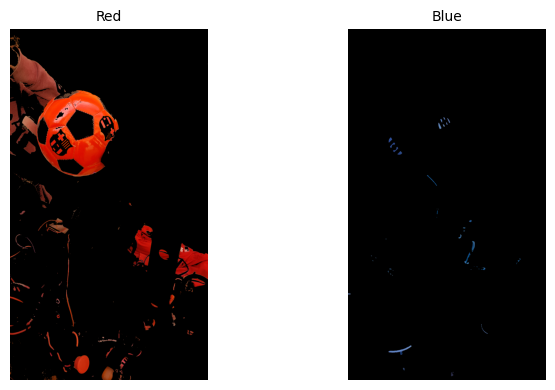

Red Ball: center=(644,1018) r=346, 4820 circle(s) detected
No circle found for Blue Ball


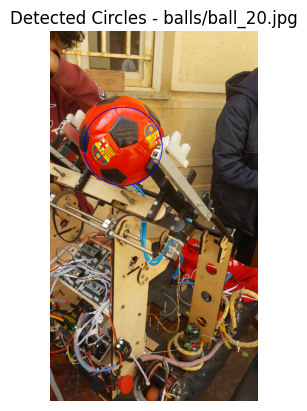

In [15]:

for i in range(1, 21):
    IMAGE_PATH = f"balls/ball_{i}.jpg"
    MAX_W, MAX_H = 10000, 10000

    bgr = cv2.imread(IMAGE_PATH)
    if bgr is None:
        print(f"Could not read {IMAGE_PATH}")
        continue

    img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    scale = min(MAX_W / w, MAX_H / h, 1.0)
    resized = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)

    print(f"--- {IMAGE_PATH} ({resized.shape[1]}x{resized.shape[0]}) ---")

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    kernelb = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

    hsv = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([0, 80, 60])  # 100
    upper_blue = np.array([17, 255, 240]) #255
    blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)
    blue_mask = cv2.morphologyEx(blue_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    blue_objects = cv2.bitwise_and(resized, resized, mask=blue_mask)

    lower_red = np.array([108, 100, 95])
    upper_red = np.array([140, 255, 255])
    red_mask = cv2.inRange(hsv, lower_red, upper_red)
    red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, kernelb, iterations=1)
    red_objects = cv2.bitwise_and(resized, resized, mask=red_mask)

    show_row([("Red", red_objects, None), ("Blue", blue_objects, None)])

    red_ball, red_ball_gray = extract_ball(red_mask, resized, label="Red Ball")
    blue_ball, blue_ball_gray = extract_ball(blue_mask, resized, label="Blue Ball")



    red_circle = detect_circle(red_ball_gray, resized, label="Red Ball", color=(0, 0, 255))
    blue_circle = detect_circle(blue_ball_gray, resized, label="Blue Ball", color=(255, 0, 0))

    show(resized, title=f"Detected Circles - {IMAGE_PATH}")